# **Introduction to Convolutional Neural Networks**

### [Matteo De Matola](https://github.com/matteo-d-m) 

This Jupyter Notebook contains code and textual explanations to accompany the paper:

**Convolutional Neural Networks and Neuroscience: A Tutorial Introduction for The Rest Of Us, by Matteo De Matola and Giorgio Arcara (2026)**

The code in the notebook can be run locally (see instructions) or in Google Colab. 
Google Colab is suggested if you want to run all the code (including training) and you don't have a powerful laptop. 
Press the button below for Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/coneco-lab/open-lab-toolkit/blob/main/tutorials/convnets-tutorial.ipynb)

## **Foreword**

Convolutional neural networks (CNNs) are a class of artificial neural networks that are widely used across several domains.

In the last ten years, CNNs have been increasingly used in neuroscience as:
- Models of the ventral visual stream 
- EEG classifiers
- MRI classifiers 
- EEG forecasters
- & more

Due to their popularity in neuroscientific research, it is increasingly important to understand what CNNs are and how to implement them, finding the right balance between formal rigour and accessibility to a broad scientific audience. The paper by De Matola \& Arcara pursues exactly this goal, and this Jupyter Notebook is its companion. 

This notebook cannot provide a throrough treatment of CNNs' theory and applications, nor can it be mathematically rigorous. But it will:
- Provide all the basic definitions 
- Introduce all the essential Python tools
- Build a working CNN for object recognition, step-by-step
- Provide pointers to external resources (e.g., papers, books, and online courses) to deepen your understanding of CNN theory

The material in this notebook was taught by ([Matteo De Matola](https://github.com/matteo-d-m)) in Lecture 3.3 of [Python for (open) Neuroscience](https://github.com/vigji/python-cimec-2024) (2024 iteration), a course by Luigi Petrucco at the University of Trento's doctoral school in Cognitive \& Brain Sciences. 

The tutorial assumes _some_ Python knowledge (at least the ability to read code and understand what it does in general terms). If needed, the Petrucco course is a good reference for basic and intermediate Python concepts.

# **Part 1: The Concepts** <a class="anchor" id="part-1-the-concepts"></a>

There are at least three ways to treat convolutional neural networks: 
- The mathematical way, which treats CNNs as combinations of linear and nonlinear functions
- The computational way, which treats CNNs as computer programs that take in inputs and return outputs 
- The neuroscientific way, which treats CNNs as models of perceptual pathways in the mammalian brain

All three ways are valid, and the choice between them depends entirely on the target audience.

The target audience of this notebook are neuroscientists, so I will emphasize the neuroscientific way. But I will borrow some tools and concepts from the mathematical and computational ways when needed. 

## **Core Concept 1: Artificial Neural Networks** <a class="anchor" id="first-concept"></a> 

As mentioned above, CNNs are a class of artificial neural networks (ANNs). 

ANNs are mathematical models of networks of interacting biological neurons. While their biological plausibility is debatable, ANNs have proven able to simulate some aspects of animal cognition, such as learning, vision, language, and executive control. 

### **1.1. The Artificial Neuron** <a class="anchor" id="11-the-artificial-neuron"></a>

The artificial neuron is the cornerstone of artificial neural networks. 

It is a mathematical model (basically, one equation) that represents a neuron as a weighted sum:

Given: 
- $ \mathbf{x} = [x_{1},x_{2},x_{3},...,x_{n}]  $ 
- $ \mathbf{w} = [w_{1},w_{2},w_{3},...,w_{n}]  $ 

Calculate: 

$ \displaystyle a = \sum_{i = 1}^{n} w_{i}x_{i} = w_{1}x_{1} + w_{2}x_{2} + w_{3}x_{3} + ... + w_{n}x_{n} $

where

- $ \mathbf{x} $ = a vector that stores $ n $ input values
- $ \mathbf{w} $ = a vector that stores $ n $ corresponding weights
- $ a = $ the neuron's activation

This is meant 
to model three biological facts:
1. Real neurons receive **inputs** from multiple synapses
2. Different synapses have different **strengths**, therefore, the corresponding inputs have different _weights_ (i.e., importance, salience, relevance...)
3. Postsynaptic potentials (and _action_ potentials) are a **sum** of the local potentials generated by synaptic activity

An artificial neuron may have a _bias_ term ($b$) to represent its baseline activity: 

$$ a = b + \sum_{i = 1}^{n} w_{i}x_{i} = b + w_{1}x_{1} + w_{2}x_{2} + w_{3}x_{3} + ... + w_{n}x_{n} $$

The code below implements an artificial neuron that receives a three-dimensional (random) input. 

In linear algebra jargon, the weighted sum of inputs is the _dot product_ between vector $\vec{w}$ and vector $\vec{x}$. This is why the corresponding NumPy function is called `dot()`.

In [2]:
import numpy as np 
np.random.seed(0)

def artificial_neuron(inputs, weights, bias=0):
    activation = bias + np.dot(inputs, weights) 
    return activation

NUMBER_OF_INPUTS = 3
inputs_vector = np.random.rand(1,NUMBER_OF_INPUTS)
weights_vector = np.random.randn(NUMBER_OF_INPUTS,1)

neuronal_activation = artificial_neuron(weights=weights_vector,
                                        inputs=inputs_vector,
                                        bias=0)

print(f"Inputs:{inputs_vector.tolist()}")
print(f"Weights:{weights_vector.tolist()}")
print(f"Activation:{neuronal_activation}")

Inputs:[[0.5488135039273248, 0.7151893663724195, 0.6027633760716439]]
Weights:[[-2.268328201180374], [1.3335453816218967], [-0.8427240538292873]]
Activation:[[-0.79911487]]


#### **1.1.1. The Activation Function** <a class="anchor" id="111-the-activation-function"></a>

The computation of the neuron's activation value is usually followed by a nonlinear function that we call the _activation function_ ( $f$ ):

$$ o = f(a) $$

where

- $o$ = the neuron's output
- $a$ = the neuron's activation (weighted sum of its inputs)
- $f$ = some nonlinear function

The role of the activation function is to account (or at least, try to account) for the nonlinear nature of true neuronal activity.

The ANNs literature contains a wealth of activation functions. One classic example is the sigmoid function:

$$ \sigma = \frac{1}{(1+e^{-x})} $$

While it might look complex, the sigmoid does little more than compressing the input between 0 and 1:

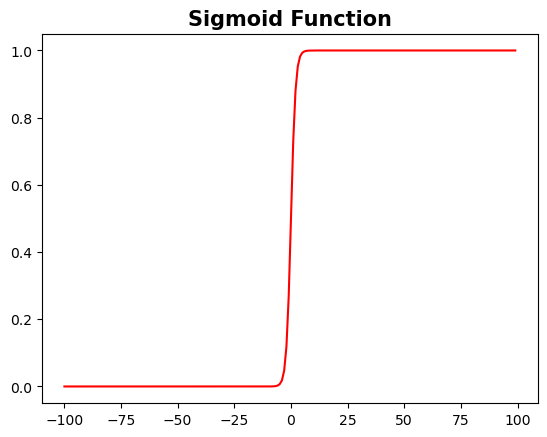

In [7]:
import matplotlib.pyplot as plt

def sigmoid(x):
    sigmoid = 1 / (1 + np.exp(-x))
    return sigmoid

input_values = np.array([n for n in range(-100,100)])
sigmoid_values = sigmoid(x=input_values)
plt.plot(input_values, sigmoid_values, "red")
plt.title(label="Sigmoid Function",
          fontweight="bold",
          fontsize=15);

The sigmoid has been important in the past, but is not much used nowadays.

A more modern activation function is the rectified linear unit (ReLU), which sets all negative values to zero and leaves all non-negative values as they were:

$$
ReLU(x) = \begin{cases}
                            x \text{  if  } x \geq 0 \\ 
                            0 \text{  otherwise}
                    \end{cases}
$$

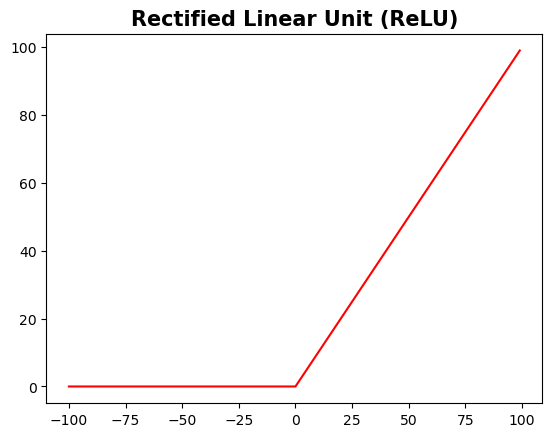

In [9]:
def relu(x):
    smaller_than_zero = (x <= 0)
    relu_values = x.copy()              # because the next line works inplace
    relu_values[smaller_than_zero] = 0    
    return relu_values

input_values = np.array([n for n in range(-100,100)])
relu_values = relu(x=input_values)
plt.plot(input_values, relu_values, "red")
plt.title(label="Rectified Linear Unit (ReLU)",
          fontweight="bold",
          fontsize="15");

If you think about it, ReLU actually picks the maximum among 0 and $ x $. Therefore, it is more compactly written as:

$$ ReLU(x) = max(0,x) $$

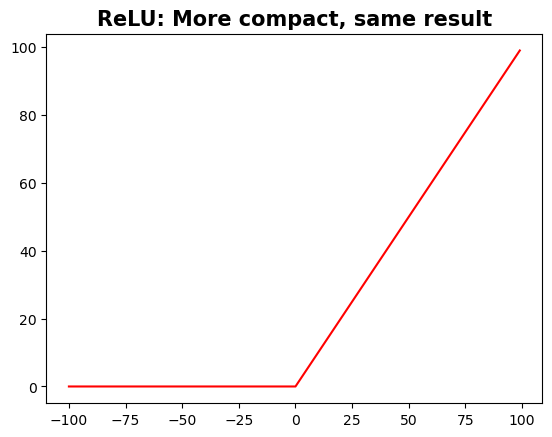

In [11]:
def relu(x):
    return np.maximum(0,x)

input_values = np.array([n for n in range(-100,100)])
relu_values = relu(x=input_values)
plt.plot(input_values, relu_values, "red")
plt.title(label="ReLU: More compact, same result",
          fontweight="bold",
          fontsize=15);

Here's the effect of sigmoid and ReLU functions on a neuron's activation:

In [12]:
with_sigmoid_activation = sigmoid(neuronal_activation)
with_relu_activation = relu(neuronal_activation)

print(f"Neuron's activation value (before any nonlinearity): {neuronal_activation} | After sigmoid: {with_sigmoid_activation}") 
print(f"Neuron's activation value (before any nonlinearity): {neuronal_activation} | After ReLU: {with_relu_activation}") 

Neuron's activation value (before any nonlinearity): [[-0.79911487]] | After sigmoid: [[0.31021489]]
Neuron's activation value (before any nonlinearity): [[-0.79911487]] | After ReLU: [[0.]]


**Interim Summary: The Artificial Neuron in a Nutshell**

- The artificial neuron is a mathematical model of the biological neuron
- Akin to the biological neuron, it receives multiple inputs. Different inputs have different weights (a.k.a. importance, salience, relevance...)
- The artificial neuron is a weighted sum of inputs. It literally **IS** that: a mathematical operation
- To account for the nonlinear behaviour of biological neurons, we feed the activations of artificial neurons into nonlinear functions

<p align="center">
  <img src="./files/artificial-neuron.png" />
</p>

### **1.2. From Neuron to Network** <a class="anchor" id="12-from-neuron-to-network"></a>

So... To model a single neuron, we multiply two vectors ($\mathbf{w}$ and $\mathbf{x}$):
- One vector contains input data ($\mathbf{x}$)
- One vector contains the corresponding weights ($\mathbf{w}$)

To model a larger set of neurons (i.e., a network), we must multiply the vector of inputs ($\mathbf{x}$) for a whole _matrix_ of weights ($\mathbf{W}$). This matrix will have:

- One row for each neuron in the network
- One column for each input

This really won't change anything but the number of neurons involved.

Given:

- $ \mathbf{x} = [x_{1},x_{2},x_{3},...,x_{n}]  $

- $W = \displaystyle \begin{bmatrix} w_{11} & w_{12} & w_{13} & ... &  w_{1n}   \\
                                     w_{21} & w_{22} & w_{23} & ... &  w_{2n}   \\
                                     w_{31} & w_{32} & w_{33} & ... &  w_{3n}   \\
                                     \vdots & \vdots & \vdots & \ddots & \vdots \\
                                     w_{m1} & w_{m2} & w_{m3} & ... & w_{mn}     \end{bmatrix}$  

Calculate: 

$ \mathbf{a} = [a_{1},a_{2},a_{3},...,a_{m}]  $

where

- $ \mathbf{x} = $ a vector that stores $ n $ input intensity values
- $ \mathbf{W} = $ a matrix that stores $ n $ corresponding weights for each of $ m $ neurons
- $ \mathbf{a} = $ a vector that stores $ m $ activation values (one for each neuron)

Each element of $ \mathbf{a} $ is the dot product (weighted sum) between $ \mathbf{x} $ and one row of the weights matrix: 


$ \displaystyle a_{i} = \sum_{j = 1}^{n} w_{ij}x_{j} = w_{i1}x_{1} + w_{i2}x_{2} + w_{i3}x_{3} + ... + w_{in}x_{n} $ 

where 

- $ a_i = $ the activation value of the $ i^{th} $ neuron

Here's what all looks like in video:

<video width="1000" height="auto" controls>
  <source src="./files/mat-vec-mul.mp4" type="video/mp4">
</video>

(if you can't see the video, you can try at [this](https://drive.google.com/file/d/1-WJdkdwY71ADE5rSXKYQEnoJ6gpKqenG/view?usp=drive_link) link)

And here's what it all looks like in code:

In [7]:
def artificial_neural_network(inputs, weights, bias=0):
    network_activation = bias + np.dot(inputs, weights) 
    return network_activation

NUMBER_OF_INPUTS = 3
NUMBER_OF_NEURONS = 3
some_random_inputs = np.random.rand(1,NUMBER_OF_INPUTS)
some_corresponding_weights = np.random.randn(NUMBER_OF_NEURONS,NUMBER_OF_INPUTS)

network_activation = artificial_neural_network(inputs=some_random_inputs,
                                               weights=some_corresponding_weights,
                                               bias=0)
with_sigmoid = sigmoid(network_activation)
with_relu = relu(network_activation)

print(f"Network activation (before any nonlinearity): {network_activation} | After sigmoid: {with_sigmoid}")
print(f"Network activation (before any nonlinearity): {network_activation} | After ReLU: {with_relu}")

Network activation (before any nonlinearity): [[2.61805374 0.8185998  1.64595012]] | After sigmoid: [[0.93201449 0.69393904 0.83834295]]
Network activation (before any nonlinearity): [[2.61805374 0.8185998  1.64595012]] | After ReLU: [[2.61805374 0.8185998  1.64595012]]


**Interim summary: From Neuron to Network in a Nutshell**

- An ANN is a mathematical model of a _network_ of neurons
- An ANN is composed of _multiple_ artificial neurons (so-called _nodes_) 
    - Each neuron is a weighted sum of inputs followed by a nonlinear function

### **1.3. From Network to Deep Network** <a class="anchor" id="13-from-network-to-deep-network"></a>

- The multiplication between a vector of inputs and a matrix of coefficients yields the activity of a set of neurons. This set of neurons is called a _network layer_.
    - Analogy: a brain area

- But, what if we have _multiple_ sets of neurons that communicate with each other?
    - One brain area that sends signals to another area, that sends them to another one, that sends them to another one...

- To simulate this situation, we just concatenate multiple layers
    - The output of a set of neurons becomes the input to another one
    - Eventually, the output from the whole network will be shaped by each layer's output

Here's what it looks like in code:

In [14]:
def network_layer(inputs, weights, bias, activation_function=None):
    layer_activation = bias + np.dot(inputs, weights) 
    if activation_function:
        return activation_function(layer_activation)
    else:
        return layer_activation
    
NUMBER_OF_INPUTS = 3
NUMBER_OF_NEURONS = 3

data_vector = np.random.rand(1,NUMBER_OF_INPUTS)
layers_weights_list = [np.random.randn(NUMBER_OF_NEURONS,NUMBER_OF_INPUTS) for layer in range(3)]
layer_input = data_vector
for layer_number, layer_weights in enumerate(layers_weights_list):
    layer_output = network_layer(inputs=layer_input,
                                 weights=layer_weights,
                                 bias=0,
                                 activation_function=None)
    print(f"Layer {layer_number+1} activation: {layer_output}")
    layer_input = layer_output

Layer 1 activation: [[2.61805374 0.8185998  1.64595012]]
Layer 2 activation: [[ 5.09058302 -3.92225461 -7.21608444]]
Layer 3 activation: [[12.73297639  8.8300536   9.83378717]]


**Interim summary: From Network to Deep Network in a Nutshell**

- A deep network is a chain of layers
    - Each layer's output is the input to the next
    - The output from each layer contributes to the output from the whole network

- Each layer is itself a chain of two operations:
    - Multiplication between $\mathbf{W}$ and $\mathbf{x}$  
    - A nonlinear activation function ( $f$ )

## **Core Concept 2: From (Deep) Network to (Deep) Convolutional Network** <a class="anchor" id="second-concept"></a>

### **2.1. The Problem of Bidimensional Inputs** <a class="anchor" id="21-the-problem-of-bidimensional-inputs"></a>

As described above, a standard neural network layer consists of:

- Multiplication between $\mathbf{W}$ (a weights matrix) and $\mathbf{x}$ (a vector of data) 
- A nonlinear activation function ( $f$ )

The output of such layer is $\mathbf{a}$, a vector of neuronal activation values (one value for each neuron in the layer). 

Such standard network layers work well for vector inputs, i.e., things like:

$$ \mathbf{x} = [x_{1},x_{2},x_{3},...,x_{n}]  $$

In practice, such inputs might be EEG data from a given electrode, in a given time window (one number per time point): 

$$ EEG \ (\mu V) = [0.1, 0.16, -0.1, ..., 0.24] $$

or the mean rent in [Rovereto](https://en.wikipedia.org/wiki/Rovereto) districts at any given time (one number per district):

$$ Rent \ (€) = [650, 765, 880, ..., 710] $$

or anything else that can be described by a one-dimensional array. 

But, what do we do with grid-like, two-dimensional inputs?

For example, what do we do with EEG data from several electrodes?

 $$ EEG \ (\mu V) = \begin{bmatrix}
0.12 & 0.16 & -0.10  & ... &  0.24 \\
0.17 & 0.23 & -0.21 & ... &  0.33 \\
1.33 & 0.97 & -0.34 & ... &  0.26 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1.01   & 1.41 & 1.27 & ... & -2.35 
\end{bmatrix}    $$  

And, what do we do with an image (which is just a grid of colour - or luminance - values)?

<p align="center">
  <img src="./files/birdie.jpg" />
</p>

In principle, grid-like inputs could be multiplied by a weights matrix, like their vector counterparts. 

Given:

 - $ \mathbf{X} = \displaystyle \begin{bmatrix} x_{11} & x_{12} & x_{13} & ... &  x_{1m}    \\
                                       x_{21} & x_{22} & x_{23} & ... &  x_{2m}    \\
                                       x_{31} & x_{32} & x_{33} & ... &  x_{3m}    \\
                                       \vdots & \vdots & \vdots & \ddots & \vdots  \\
                                       x_{n1} & x_{n2} & x_{n3} & ... & x_{nm}      \end{bmatrix}    $ 

- $ \mathbf{W} = \displaystyle \begin{bmatrix} w_{11} & w_{12} & w_{13} & ... &  w_{1n}   \\
                                      w_{21} & w_{22} & w_{23} & ... &  w_{2n}   \\
                                      w_{31} & w_{32} & w_{33} & ... &  w_{3n}   \\
                                      \vdots & \vdots & \vdots & \ddots & \vdots \\
                                      w_{m1} & w_{m2} & w_{m3} & ... & w_{mn}    \end{bmatrix}    $ 

We would calculate: 

- $ \mathbf{WX} = \mathbf{A} = \displaystyle \begin{bmatrix} a_{11} & a_{12} & a_{13} & ... &  a_{1m}   \\
                                           a_{21} & a_{22} & a_{23} & ... &  a_{2m}   \\
                                           a_{31} & a_{32} & a_{33} & ... &  a_{3m}   \\
                                           \vdots & \vdots & \vdots & \ddots & \vdots \\
                                           a_{m1} & a_{m2} & a_{m3} & ... & a_{mm}    \end{bmatrix}    $  

where

- $ \mathbf{X} = $ a matrix that stores $ n \cdot m $ intensity values of a bidimensional input
- $ \mathbf{W} = $ a matrix that stores $ n \cdot m $ corresponding weights
- $ \mathbf{A} = $ a matrix that stores $n \cdot n$ activation values for as many neurons

Each element of $ \mathbf{A} $ would be the dot product (weighted sum) between one row of $ \mathbf{W} $ and one column of $ \mathbf{X} $: 


$ \displaystyle a_{ij} = \sum_{j = 1}^{n} w_{ij}x_{ji} = w_{i1}x_{1i} + w_{i2}x_{2i} + w_{i3}x_{3i} + ... + w_{in}x_{ni}  \ \ \forall \ \ i : 1 \leq i \leq \ m $

where 

- $ a_{ij} $ is the response of the $ i^{th} $ neuron to the $ j^{th} $ column of the input matrix 


While feasible, this strategy is:

- Quite complex 
  - It has no straightforward neuroscientific meaning 
  - If you tried it out with paper and pencil, you might have a hard time wrapping your mind around it
- Very inefficient
    - It neglects the compositional structure of inputs
      - Wait - what is this?

### **2.2. Convolution Captures Local Structures** <a class="anchor" id="22-convolution-captures-local-structures"></a>

Often, grid-like inputs are a composition of local structures, or _**features**_:

- An image is composed of edges, circles, and other geometric primitives
- An EEG is composed of different patterns of activity from different electrodes
- etc.

To capture this local structure, we can:

- Take a small weights matrix (smaller than the input) 
- Overlay this small weights matrix to an equally small patch of the input
- Multiply the small weights matrix and the small patch of input element-wise
- Sum all the element-wise products
- Repeat on a different patch until the whole input is covered

This operation is known as _**convolution**_ and is equivalent to taking the dot product between a patch of input and a set of weights.

Note that:

- Convolution returns weighted sums of inputs that are specific to a given input region, that is, that represent a specific _feature_
- We can interpret the result of convolution in terms of sensory neurons and their receptive fields

This is better explained in video:

<video width="1000" height="auto" controls>
  <source src="./files/discrete-conv.mp4" type="video/mp4">
</video>

(if you can't see the video, you can try at [this](https://drive.google.com/file/d/1EFHcrd1qlkoKGb3yVJVUb33sSk1EMcI3/view?usp=drive_link) link)

Understanding convolution requires to know three terms and understand their meaning:

1. **Kernel:** the weights matrix. It's also called _filter_
    - These terms are inherited from the fields of image and signal processing, where convolution is very popular

2. **Padding:** a frame of zeros around the image. If the size of your kernel is such that the kernel might end up outside the input, you must pad the input with zeros - otherwise, Python will throw an error. This has no impact on the result, as the element-wise products of kernel values and padding values will be 0 

3. **Stride:** the size of each kernel's step

Now that we know the jargon, we can implement a convolution in pure NumPy:

In [10]:
input_height, input_width = 10, 10
gridlike_input = np.random.rand(input_height,input_width)

kernel_height, kernel_width = 2, 2
convolution_kernel = np.random.randn(kernel_height,kernel_width)

padding = 0
horizontal_stride, vertical_stride = kernel_width, kernel_height

output_height = int((input_height + 2*padding - kernel_height) / vertical_stride) + 1   # law
output_width = int((input_width + 2*padding - kernel_width) / horizontal_stride) + 1    # law
feature_map = np.zeros((output_height,output_width))

width_covered, height_covered, convolution_steps  = 0, 0, 0
for row in range(output_height):
    for column in range(output_width):
        input_patch = gridlike_input[height_covered:kernel_height+height_covered,
                                     width_covered:kernel_width+width_covered]
        feature_map[row,column] = np.sum(input_patch*convolution_kernel)
        width_covered += horizontal_stride
        convolution_steps += 1
        print(f"Feature map after {convolution_steps} convolution steps:")
        print(feature_map)
        print(" ")
    width_covered = 0
    height_covered += vertical_stride

Feature map after 1 convolution steps:
[[-0.12440908  0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
 
Feature map after 2 convolution steps:
[[-0.12440908 -0.36729868  0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
 
Feature map after 3 convolution steps:
[[-0.12440908 -0.36729868 -0.91943058  0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.     

The convolution of a grid-like input with a kernel is a special type of network layer that we call _convolutional layer_. 

As it happens for standard network layers, the outputs of convolutional layers are fed into an activation function: 

In [37]:
print("Convolutional layer's output:")
print(feature_map)
print(" ")
print("After sigmoid:")
print(sigmoid(feature_map))
print(" ")
print("After ReLU:")
print(relu(feature_map))
print(" ")

Convolutional layer's output:
[[-1.23817652 -1.46680156 -1.84511203 -1.48882105 -1.14332562]
 [-0.81269752 -0.99558594 -0.14698761 -0.0392411  -0.19709268]
 [-0.7373588   0.09556448 -0.23547217 -0.79852495 -1.55174144]
 [ 0.45222714 -0.95114362 -0.95163147  0.16110262 -0.95440813]
 [ 0.18712797 -0.90035503  0.35852819  0.12599117  0.13146387]]
 
After sigmoid:
[[0.22475355 0.18742925 0.13644782 0.18409875 0.2417103 ]
 [0.30731597 0.26981016 0.46331912 0.49019098 0.45088572]
 [0.32358197 0.52387296 0.44140246 0.31034113 0.17483489]
 [0.61116862 0.27865489 0.27855684 0.54018877 0.27799918]
 [0.54664595 0.28897754 0.5886841  0.53145619 0.53281872]]
 
After ReLU:
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.09556448 0.         0.         0.        ]
 [0.45222714 0.         0.         0.16110262 0.        ]
 [0.18712797 0.         0.35852819 0.12599117 0.13146387]]
 


And as it happens with standard network layers, convolutional layers can be concatenated into a deep network!

[Back to top](#back-to-top)

## **Core Concept 3: Error-Driven Learning** <a class="anchor" id="core-concept-3-error-driven-learning"></a>

### **3.0. Weights Shape Everything** <a class="anchor" id="30-weights-shape-everything"></a>

So... Every layer in a network takes in something and transforms it into something else. The exact shape of this transformation depends on the weights, meaning that the same input can yield entirely different outputs if combined with different weights:

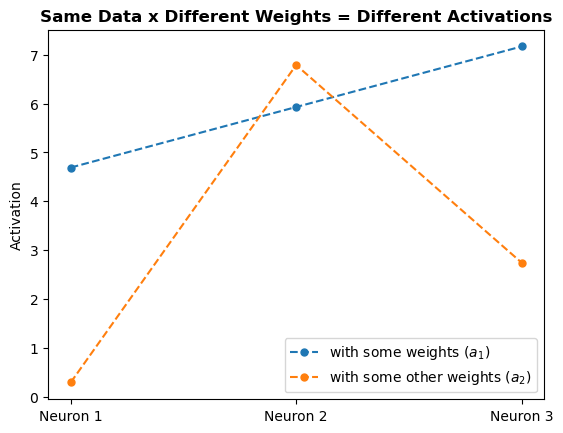

In [21]:
input_vector = np.array([0.27,0.79,0.18])
some_weights = np.array([[1,2,3],
                         [4,5,6],
                         [7,8,9]])
some_other_weights = np.array([[0,2,3],
                               [1/4,7,1/6],
                               [1/2,4,10]])

activation_with_some_weights = network_layer(inputs=input_vector,
                                             weights=some_weights,
                                             bias=0,
                                             activation_function=None)
activation_with_some_other_weights = network_layer(inputs=input_vector,
                                                   weights=some_other_weights,
                                                   bias=0,
                                                   activation_function=None)

_, ax = plt.subplots()
ax.plot(activation_with_some_weights.T, 
        marker=".",
        markersize=10,
        linestyle="dashed",
        label="with some weights ($a_1$)");
ax.plot(activation_with_some_other_weights.T, 
        marker=".",
        markersize=10,
        linestyle="dashed",
        label="with some other weights ($a_2$)");
ax.set_title(label="Same Data x Different Weights = Different Activations",
             fontweight="bold",
             fontsize=12);
ax.set_xticks(ticks=[0,1,2],
              labels=["Neuron 1", "Neuron 2", "Neuron 3"],
              fontsize=10);
ax.set_ylabel(ylabel="Activation",
              fontsize=10)
ax.legend();

We face two related facts:

1. An ANN's output is shaped by the weights
    - When weights change, so does the output
2. If you want a network to produce a given output, you need to change the weights

These facts create a problem: how can you change the weights towards a desired outputs?
- You do _**error driven learning**_ 

### **3.1. What is Error-Driven Learning?** <a class="anchor" id="31-what-is-error-driven-learning"></a>

Error-driven learning is a simple algorithm (i.e., a sequence of actions):

1. Feed your data into the ANN
2. Compare the output to a target (i.e., a desired output)
3. Calculate the error
3. Change the weights 
4. Repeat until the error tends to zero

### **3.2. The Rules of Error-Driven Learning** <a class="anchor" id="32-the-rules-of-error-driven-learning"></a>

In order to work, error-driven learning must obey three rules:

1. Weights must change in a way that minimises the error

2. Different weights must change differently
    - Because some contribute to the error more than others
    
3. Weights cannot change at random
    - Otherwise, learning might take forever

### **3.3. The Prerequisites for Error-Driven Learning** <a class="anchor" id="33-the-prerequisites-for-error-driven-learning"></a>

In light of its rules, error-driven learning needs:

1. An error function (a.k.a. _loss_ function)
    - To compute the distance between real and desired output

2. A [derivative](https://en.wikipedia.org/wiki/Derivative) of the error function with respect to the weights
    - To quantify the contribution of each weight to the error function  
    
3. A rule to change weights appropriately
    - Often, that's error backpropagation

### **3.4. Error Backpropagation** <a class="anchor" id="34-error-backpropagation"></a>

Error backpropagation is the most basic and most common rule to change weights. 

In error backpropagation, we subtract from each weight a small fraction of its contribution to the error: 

$$ w_i \leftarrow w_i - \alpha \frac{\delta L_{\vec{w}}}{\delta w_i} $$

where

- $ w_i = $ any given weight

- $ \alpha = $ the _learning rate_, i.e., an arbitrary coefficient between 0 and 1

- $ \displaystyle \frac{\delta L_{\vec{w}}}{\delta w_i} = $ the derivative of loss function $ L $ with respect to $ w_i $
    - That's a measure of $ w_i $'s contribution to $ L $

Note that $ \displaystyle \frac{\delta L_{\vec{w}}}{\delta w_i}  $ can be positive or negative

- If it's positive, it means that the weight is increasing the error
    - We don't like that weight and we decrease it 
- If it's negative, it means that the weight is decreasing the error
    - We like that weight and we increase it 

(the key to seeing these facts is that minus times plus equals minus, while minus times minus equals plus)

### **3.5. Training, Validation, and Testing** <a class="anchor" id="35-training-validation-and-testing"></a>

Usually, we don't want an algorithm to produce a desired output _once_. We want it to produce the desired output _forever_. 

To produce a desired output in a stable fashion, an algorithm must acquire **strong** knowledge about a given domain
- For example, learn to recognise an image as containing a cat, everytime there is cat 

Knowledge is strong when it's based on the intrinsic, defining features of the data. Strong knowledge is:
- Robust to small, contextual changes of the data 
    - You must recognise a cat regardless of it being brown, black, or spotted
- Based on the data of interest, not on spurious covariates
    - You must recognise a cat because it's a cat, not because it's always close to a cup of milk. Otherwise, you won't recognise it when you see it without milk    

ANNs, CNNs, and other [machine learning](https://en.wikipedia.org/wiki/Machine_learning) algorithms acquire strong knowledge when: 

- They are exposed to a **large** body of data 
    - The more you see, the more you learn
- They are exposed to a **rich** body of data 
    - Not all cats are brown
- They can generalise their knowledge
    - You can't see all the cats in the world. But when you meet a new cat, you must recognise it as such

To favour strong knowledge, a typical learning algorithm undergoes three phases:

- **Training:** the algorithm does error-driven learning on a (hopefully large) body of data. Recall that _error-driven learning_ means:

    1. Feed your data into the ANN
    2. Compare the output to a target (i.e., a desired output)
    3. Calculate the error
    3. Change the weights 
    4. Repeat until the error tends to zero
- **Validation:** every $ n $ training iterations, the algorithm is fed some previously unseen samples
    - Weights are not changed
    - This is just an online sanity check for the training process
- **Testing:** at the end of the training/validation cycle, the algorithm is fed some more previously unseen samples
    - Weights are not changed
    - This is the moment of truth: has the algorithm acquired robust knowledge?

[Back to top](#back-to-top)

# **Part 2: The Implementation** <a class="anchor" id="part-2-the-implementation"></a>

So far, we have seen toy examples of artificial neurons and ANN layers. 

Despite dealing with simplified scenarios, the code examples got more and more complex as we progressed through the tutorial. 
- Think about the convolution example: complex-ish, no?
- Imagine coding a full network, the backpropagation algorithm, and the whole training-validation-test cycle!

To survive real-world scenarios, we need a codebase that abstracts away the details and let us focus on high-level choices. 

## **Enter: PyTorch** <a class="anchor" id="enter-pytorch"></a>

[PyTorch](https://pytorch.org/) is a Python library to build, train, and test deep artificial neural networks

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/c/c6/PyTorch_logo_black.svg" />
</p>

Like many other Python libraries, PyTorch is:
- Free
- Open source
- The result of a large-scale collaborative effort

If you use PyTorch in published work, remember to cite the authors:

[Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. _Advances in Neural Information Processing Systems_, 32](https://proceedings.neurips.cc/paper/2019/hash/bdbca288fee7f92f2bfa9f7012727740-Abstract.html)

PyTorch contains classes and functions to: 

- Download and use publicly available datasets 
- Set up any kind of ANN architecture
- Train ANNs with a variety of learning algorithms
- Exploit the parallel computing capabilities of graphics processing units (GPUs), which accelerate computations

PyTorch is fully compatible with the Python scientific computing ecosystem - in particular, it is well-integrated with NumPy. 

If you already have a [Python installation](https://github.com/vigji/python-cimec-2024/blob/main/docs/python-installation.md), you can install PyTorch via `conda` or `pip` following the instructions on the [PyTorch homepage](https://pytorch.org/). But it's probably faster to get started on Colab - especially because your computer is probably not powerful enough for deep learning. 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/coneco-lab/open-lab-toolkit/blob/main/tutorials/convnets-tutorial.ipynb)

Once installed (or, once opened this notebook in Colab), you can start using PyTorch with a simple import statement:

In [1]:
import torch

## **Tensors, Datasets, & DataLoaders** <a class="anchor" id="tensors-datasets--dataloaders"></a>

In the following, we will use PyTorch to build a CNN for image recognition. Therefore, we will need some images to work with. 

PyTorch has a companion library that contains classes and functions to work with images. This companion library is called `torchvision`.

Among other things, `torchvision` contains a `datasets` package (a package is a collection of `.py` files), which provides tools to download and use publicly available image datasets. 

We will use the [MNIST dataset of handwritten digits](https://en.wikipedia.org/wiki/MNIST_database), which contains $70000$ handwriting samples of the numbers from $0$ to $9$, encoded as $28$ x $28$ grids of grayscale luminosity values:

<p align="center">
  <img src="./files/mnist-samples.png" />
</p>

(image from Wikipedia)

The code below downloads MNIST from its online repository. We do two separate downloads for the training and test datasets, assigning each to a separate variable.  

In [2]:
import torchvision
import torchvision.transforms as transforms

training_dataset = torchvision.datasets.MNIST(root="classifier data", 
                                              train=True, 
                                              download=True, 
                                              transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(root="classifier data", 
                                          train=False, 
                                          download=True, 
                                          transform=transforms.ToTensor())

The variables that we created are _dataset objects_. A dataset object implements two crucially important methods:

- `__len__()`, which allows users to get the dataset's length
- `__getitem__()`, which allows users to index into the dataset

The double underscore before and after the two methods' names tells us that those methods are default. This means that we don't call them explicitly, but they work under the hood when we call `len(dataset)` and `dataset[index]`, respectively.

Let's leverage `__len__()` to check how many samples we have:

In [3]:
training_dataset_length = len(training_dataset)
test_dataset_length = len(test_dataset)

print(f"The training dataset contains {training_dataset_length} samples, while the test dataset contains {test_dataset_length}.")

The training dataset contains 60000 samples, while the test dataset contains 10000.


In [4]:
training_dataset_length = len(training_dataset)
test_dataset_length = len(test_dataset)

print(f"Training: {training_dataset_length} | Test: {test_dataset_length}.")

Training: 60000 | Test: 10000.


Not bad! Now let's leverage `__getitem__()` to inspect those samples and see what they look like. 

We will use one training sample as case study, but everything will apply equally to test samples.

In [5]:
one_training_sample = training_dataset[0]

We extracted one sample from the training dataset. But, what type of data structure is it?

In [6]:
type(one_training_sample)

tuple

Apparently, each sample is a tuple. How many elements are contained in it?

In [7]:
len(one_training_sample)

2

Two items in each tuple! What are those items?

- The first item is an image
- The second item is a label that communicates the content of the image

To make things clearer, let's [unpack the tuple](https://realpython.com/python-tuple/#packing-and-unpacking-tuples) and assign each of its items to a separate variable with an explanatory name.  

In [8]:
image, label = one_training_sample

Now let's delve a bit deeper into both variables, starting from the label:

In [9]:
print(f"This sample's label is: {label}. Its datatype is: {type(label)}")

This sample's label is: 5. Its datatype is: <class 'int'>


Apparently, the image contains a 5. Its label is a number (indeed, $5$) that's encoded as an `int`.  

But, how is the image encoded? In other words, what type of data structure is it?

In [10]:
type(image)

torch.Tensor

The image is encoded as a PyTorch tensor! 

A tensor is basically an array with an arbitrary number of dimensions: while a vector has 1 dimension and a matrix has 2, a tensor can have any. 

PyTorch tensors are basically the same as NumPy arrays, except that:
- They can be loaded into GPUs
- They are optimised for fast and automatic [differentiation](https://www.britannica.com/science/differentiation-mathematics) of the functions that they represent (which is useful for backpropagation) 

These facts will make increasing sense as we proceed.

Like NumPy arrays, PyTorch tensors have a `.shape` attribute. When you access it, you get a variable of type `torch.Size` with information about the the tensor's shape:

In [11]:
print(f"The shape of our image tensor is: {image.shape}")

The shape of our image tensor is: torch.Size([1, 28, 28])


Apparently, the shape is $1$ x $28$ x $28$. This means that the tensor contains an image with $1$ channel and  $28$ x $28$ shape. 

 $1$ channel means one _colour_ channel - in other words, the image is black and white (more on this later).

 But, let's see our image!

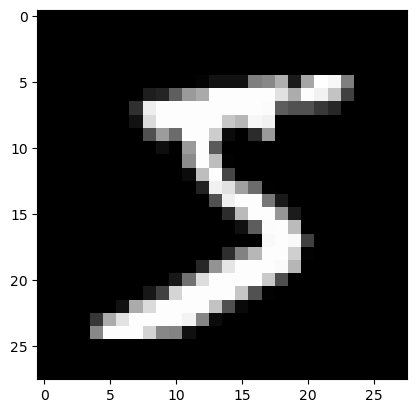

In [12]:
import matplotlib.pyplot as plt

plt.imshow(image.squeeze(), cmap="gray"); # the `.squeeze()` method suppresses the singleton dimension, allowing 2d plotting

It's not beautiful ($28$ x $28$ is low resolution), but it's a 5!

Now that we know what's in our dataset, we can use it the way we want. 

We will start by reserving a random $25$% of the training dataset for validation. 

To this end, we will use the function `random_split()` from the `data` module (contained in the `utils` package and `data` module of the PyTorch library):

In [8]:
from torch.utils.data import random_split

use_for_training = int(len(training_dataset)*0.75)
use_for_validation = int(len(training_dataset)*0.25)

training_data, validation_data = random_split(dataset=training_dataset,
                                              lengths=[use_for_training, use_for_validation],
                                              generator=torch.Generator().manual_seed(0))

print(f"The training dataset now contains {len(training_data)} samples, while the validation dataset contains {len(validation_data)}.")

The training dataset now contains 45000 samples, while the validation dataset contains 15000.


**Interim summary**

- There is a Python library called PyTorch
- PyTorch has a companion library called `torchvision`, which contains computer vision utilities
    - `torchvision` contains a package called `datasets`, which provides access to a number of freely downloadable image datasets
- Once downloaded and assigned to a variable, each dataset becomes a `Dataset` object
    - `Dataset` objects have a length
    - `Dataset` objects can be indexed to access specific samples
- Each sample in a `Dataset` object is a tuple that contains: 
    - One image
    - One label 
    
    (at least, this is true of object recognition datasets)
- Labels are encoded as `int`s, while images are encoded as Pytorch `tensor`s
- We can easily slice `Dataset` objects with PyTorch functions such as `random_split()`
- A PyTorch `tensor` is a pumped-up NumPy array

Now, `Dataset` objects can be iterated over. For example, we can do things like:

In [14]:
for sample_number in range(10):
    print(f"Sample number {sample_number+1} is a tuple of {len(training_dataset[sample_number])} items")

Sample number 1 is a tuple of 2 items
Sample number 2 is a tuple of 2 items
Sample number 3 is a tuple of 2 items
Sample number 4 is a tuple of 2 items
Sample number 5 is a tuple of 2 items
Sample number 6 is a tuple of 2 items
Sample number 7 is a tuple of 2 items
Sample number 8 is a tuple of 2 items
Sample number 9 is a tuple of 2 items
Sample number 10 is a tuple of 2 items


However, `Dataset` objects behave like standard iterables - that is, they can only retrieve one sample at a time. But when you train an ANN, you want to access multiple samples at once and process them as if they were a single tensor. This is known as **batch** (or _minibatch_) **processing**, and it can increase training speed. 

In real-world scenarios, you also want to fully exploit your machine's power and to shuffle training samples at every iteration. 

To achieve this, you need a `DataLoader` object. A `DataLoader` object takes a `Dataset` object and empowers it with: 

- Batch processing capabilities (i.e., process batches of samples as if they were a single tensor)
- Multiprocessing capabilities (i.e., use all your machine's power to access as much data as possible in parallel)
- Shuffling capabilities (i.e., access samples in a different order everytime, to avoid order effects on the learning process)

We will now create  one `DataLoader` object for each of our `Dataset` objects:

In [9]:
from torch.utils.data import DataLoader

training_loader = DataLoader(dataset=training_data,
                             batch_size=15000,
                             shuffle=True)

validation_loader = DataLoader(dataset=validation_data,
                               batch_size=len(validation_data),
                               shuffle=False)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=len(test_dataset),
                         shuffle=False)

Unlike `Dataset` objects, `DataLoader` objects cannot be indexed:

In [16]:
print(training_loader[0])

TypeError: 'DataLoader' object is not subscriptable

However, they can be iterated over. Therefore, to inspect the contents of a dataloder we need to run a loop:

In [17]:
for sample in training_loader:
    """Just print out the type, length (where applicable), and shape (where applicable) of each sample"""
    print(type(sample), ",", len(sample), "|",  type(sample[0]), ",",  sample[0].shape, "|",  type(sample[1]), ",",  sample[1].shape)

<class 'list'> , 2 | <class 'torch.Tensor'> , torch.Size([15000, 1, 28, 28]) | <class 'torch.Tensor'> , torch.Size([15000])
<class 'list'> , 2 | <class 'torch.Tensor'> , torch.Size([15000, 1, 28, 28]) | <class 'torch.Tensor'> , torch.Size([15000])
<class 'list'> , 2 | <class 'torch.Tensor'> , torch.Size([15000, 1, 28, 28]) | <class 'torch.Tensor'> , torch.Size([15000])


We see three important things:

- The `DataLoader` object contains three samples (one per batch)

- Each item is a list of two elements:

    - The first element is a tensor of shape `(batch_size, n_channels, image_height, image_width)`. It contains a batch of images

    - The second element is a tensor of shape `(batch_size)`. It contains a batch of labels

During training, we will feed data to the CNN as:

In [18]:
for batch in training_loader:
    # CNN processes batch

_IncompleteInputError: incomplete input (2112244864.py, line 2)

In other words, the CNN will process each batch as a whole, as if it were a single image.

## **Building a CNN** <a class="anchor" id="building-a-cnn"></a>

Now that we have the data and an efficient way to access them, we can feed them to a CNN. 

But first, we need a CNN.

In PyTorch, neural networks are represented as [classes](https://github.com/vigji/python-cimec-2024/blob/main/lectures/Lecture0.5_define_classes.ipynb). 

This makes sense if you think that:

- A neural network has certain structural components, which are its layers. These components will be the _attributes_ of the neural network class
- A neural network does certain things, like transforming the data. These things will be the _methods_ of the neural network class 

Whenever you code a neural network in PyTorch, you need to write a class. This class **must** inherit from the base class `Module`, which is contained in a PyTorch module called `nn` (yes, they put something called `Module` inside a module. Not helpful...).

The following code implements a convolutional neural network with two convolutional layers followed by two standard, non-convolutional layers:

In [10]:
import torch.nn as nn

class CNN(nn.Module):
  """A convolutional neural network"""

  def __init__(self, dropout_probability):                                              
    super().__init__() 
    self.conv1 = nn.Conv2d(in_channels=1, 
                           out_channels=20, 
                           kernel_size=5, 
                           stride=2)
    self.conv2 = nn.Conv2d(in_channels=20,
                           out_channels=20,
                           kernel_size=5,
                           stride=2)
    self.flatten = nn.Flatten(start_dim=1) 
    self.standard1 = nn.Linear(in_features=4*4*20, 
                               out_features=125) 
    self.standard2 = nn.Linear(in_features=125,
                               out_features=10)
    self.dropout = nn.Dropout(p=dropout_probability)
    self.activation_function = nn.ReLU()

  def forward(self, layer_input):
    layer_input = self.activation_function(self.conv1(layer_input))
    layer_input = self.activation_function(self.conv2(layer_input))
    layer_input = self.flatten(layer_input)        
    layer_input = self.activation_function(self.standard1(layer_input))
    layer_input = self.activation_function(self.dropout(layer_input))
    final_output = self.standard2(layer_input)
    return final_output 

This code contains some terms that you know, like:

- Kernel
- Stride
- Activation function

And other terms that you don't know. Let's define them, one by one:

- **Input channels (`in_channels`):** the inputs to a convolution can be elementary (like our black-and-white images), or they can result from the combination of multiple sub-inputs (like colour images, which are a combination of a Red, a Green, and a Blue image - RGB). When the input is elementary, the convolution is said to have one _input channel_. But when the input is a combination of multiple sub-inputs, the convolution is said to have _multiple_ input channels. If our input images were coloured, the convolution would have 3 input channels (one for R, one for G, and for B). In case of multiple input channels, the convolution kernel operates over each channel and the results are summed element-wise into one single feature map. But we don't care about that for now, because our inputs have a single channel (they are black and white)

- **Output channels (`out_channels`):** the number of feature maps that the convolution layer should produce. Note that to produce $n$ feature maps, we need $n$ kernels - therefore, setting the number of output channels is equivalent to setting the number of kernels that we want to use. Using multiple kernels increases the chances of building strong knowledge of the input (see below for a more detailed explanation)

- **Flatten (`nn.Flatten`):** after using multiple kernels, we want to collapse all corresponding feature maps into a single vector to feed to the standard layers. To do so, we reshape each feature map into a one-dimensional tensor (i.e., we _flatten_ it) and we concatenate the result into one big vector. This is done by the `Flatten` class contained in PyTorch's `nn` package

- **Linear (`nn.Linear`):** just a synonym for standard neural network layer, emphasizing that the layer implements a linear transformation of the input. Other synonyms that you might find are _fully connected_ and _dense_, which both emphasize how all elements of the input contribute to each element of the output (in contrast to convolutional layers, where each input patch corresponds to a well-defined portion of the feature map due to the local nature of convolutions)

- **Input features (`in_features`)  & Output features (`out_features`):** how many elements are contained in the input and output vectors of the linear layer. Note that: 

    - The input features are constrained by the size of the input tensor - be it data or the output of a previous layer. In our case, we have `in_features = 4*4*20` because the second convolutional layer outputs 20 feature maps, each of which is $4$ x $4$. This means that after flattening, we have a vector with $4$ x $4$ x $20$ = $320$ elements
    - The output features are arbitrary. However, they must make mathematical sense (i.e., they must be such that there exists a matrix to transform a vector with `in_features` elements into a vector with `out_features` elements)

- **Dropout (`nn.Dropout`):** this is a special type of layer that turns randomly selected weights into $0$, with a given probability ([Srivastava et al., 2014](https://www.jmlr.org/papers/v15/srivastava14a.html)). While relatively obscure from the theoretical standpoint, dropout is proven to improve learning 

#### **Optional: Why Using Multiple Kernels Per Layer?**

The quote below is _verbatim_ from my own master's thesis, [_A Study of Spiking Neural Networks for Biologically Plausible Deep Learning_](https://thesis.unipd.it/handle/20.500.12608/3104).

[TL;DR](https://en.wikipedia.org/wiki/TL%3BDR): using multiple kernels increases the chances of getting a good one

_"[...] there are at least two reasons why it is useful to have multiple kernels, 
the first of which is neuroscientific. [...] each kernel produces a feature
map for output. From a neuroscientific standpoint, every such feature map is
an activity pattern over H x W neurons – that is, a neuronal representation of
the input. Using multiple kernels generates multiple such representations,
simulating distributed processing in the brain (the more the kernels, the more
distributed the processing). The second argument in favour of multiple kernels
is more technical, and it has to do with the actual kernel-generation process. 
[...] convolution kernels are initialized at random [...] their initial values constrain learning
dynamics by setting a starting point to their evolutionary path. Some starting
points may be better than others, i.e., may be such that a smaller number of
weight updates is required for the network to converge to optimal performance.
In this sense, using multiple kernels increases the probability of setting an
optimal start to the learning process, and the more the kernels, the higher such
probability"._

## **Model Selection, a.k.a. Hyperparameter Tuning** <a class="anchor" id="model-selection-aka-hyperparameter-tuning"></a>

Now we have the data, an efficient way to access them, and a CNN to process them. At this point, we could start training the CNN.

However, training a neural network is a complex process that's influenced by a myriad factors - for example:

- The size of layers

- The number of layers

- The dropout probability

- The rule to update weights (there are many flavours of backpropagation)

- The value of the constants in the weights update rule
    - The most important is the  _learning rate_, that is, the $ \alpha $ in $ \displaystyle w_i \leftarrow w_i - \alpha \frac{\delta L_{\vec{w}}}{\delta w_i} $ 
        - Remember: $ 0 < \alpha < 1 $

- and countless others...

These factors are known as _**hyperparameters**_ (to distinguish them from the _parameters_, which are the network's weights).

Each possible set of hyperparameters defines a different neural network with different learning potential. Therefore, picking the right set is vital.

To pick the right set, we just try out different sets for a small number of training-validation iterations, then pick the one that yields the best results.

- This process is known as _**model selection**_ or _**hyperparameter tuning**_

Unfortunately, the space of possible sets is infinite. How do we select the sets to try? 

We have at least two options:

1. **Random search:** define the sets by random sampling of its elements
2. **Grid search:** define the sets manually, on the basis of previous knowledge about what might or might not work


We'll make the example with a grid search.

The code below defines a function to construct combinations of hyperparameter values from a dictionary, then uses it.

In [11]:
from itertools import product
from collections import namedtuple

def combine(hyperparameters):
  """Constructs combinations of hyperparameter values.

  Parameters:
  hyperparameters -- map between hyperparameter names and candidate values (dict[list])

  Returns:
  candidates -- combinations of hyperparameters values (list[namedtuple])
  """

  candidate = namedtuple("combination", hyperparameters.keys()) 
  candidates = []
  for combination in product(*hyperparameters.values()):
    candidates.append(candidate(*combination))
  return candidates

hyperparameter_values_to_try = dict(dropout_probability=[0.25, 0.5],
                                    learning_rate=[1e-2, 1e-3, 1e-4],
                                    weight_decay=[1e-4, 1e-5])  

hyperparameter_combinations = combine(hyperparameter_values_to_try)

print(f"We will try the following {len(hyperparameter_combinations)} hyperparameter combinations:")
print(" ")
for index, combination in enumerate(hyperparameter_combinations):
  print(f"{index+1}:", combination)

We will try the following 12 hyperparameter combinations:
 
1: combination(dropout_probability=0.25, learning_rate=0.01, weight_decay=0.0001)
2: combination(dropout_probability=0.25, learning_rate=0.01, weight_decay=1e-05)
3: combination(dropout_probability=0.25, learning_rate=0.001, weight_decay=0.0001)
4: combination(dropout_probability=0.25, learning_rate=0.001, weight_decay=1e-05)
5: combination(dropout_probability=0.25, learning_rate=0.0001, weight_decay=0.0001)
6: combination(dropout_probability=0.25, learning_rate=0.0001, weight_decay=1e-05)
7: combination(dropout_probability=0.5, learning_rate=0.01, weight_decay=0.0001)
8: combination(dropout_probability=0.5, learning_rate=0.01, weight_decay=1e-05)
9: combination(dropout_probability=0.5, learning_rate=0.001, weight_decay=0.0001)
10: combination(dropout_probability=0.5, learning_rate=0.001, weight_decay=1e-05)
11: combination(dropout_probability=0.5, learning_rate=0.0001, weight_decay=0.0001)
12: combination(dropout_probability=

Now that we have our combinations of hyperparameter values, we need to use them. 

Specifically, we need code to:

- Run a given number of training-validation cycles, for each combination
- Select the combination that yields the best result (i.e., the least validation loss)

The function below runs a certain number of training-validation cycles (or _epochs_, in machine learning jargon). 

In [12]:
from torch import optim 

def train_and_validate(model, device, combination, epochs, dataloaders):
  """Performs model training and validation.
  
  Parameters:
  model -- a PyTorch model instance (type: torch.nn object)
  device -- where to run computations (type: torch.device object)
  combination -- a combination of hyperparameter values (type: namedtuple)
  epochs -- number of model runs (type: int)
  dataloaders -- PyTorch dataloader instances (type: tuple)

  Returns:
  training_loss_log -- a list of training losses (one per epoch) (type: list)
  validation_loss_log -- a list of validation losses (one per epoch) (type: list)
  """

  cross_entropy_loss = nn.CrossEntropyLoss()
  optimizer = optim.Adam(params=model.parameters(), 
                         lr=combination.learning_rate,
                         weight_decay=combination.weight_decay)
  # optimizer = optim.SGD(params=model.parameters(),
  #                       lr=combination.learning_rate,
  #                       weight_decay=combination.weight_decay)
  training_loss_log = []
  validation_loss_log = []

  for epoch in range(epochs):
    training_loss = []
    model.train()
    for batch in training_loader:   
      image = batch[0].to(device)
      label = batch[1].to(device)
      output = model(image)
      loss = cross_entropy_loss(output, label)
      model.zero_grad()
      loss.backward()
      optimizer.step()
      loss = loss.detach().cpu().numpy()
      training_loss.append(loss)
    validation_loss = []
    model.eval()
    with torch.no_grad():
      for batch in validation_loader: 
        image = batch[0].to(device)
        label = batch[1].to(device)
        output = model(image)
        loss = cross_entropy_loss(output, label)
        loss = loss.detach().cpu().numpy()
        validation_loss.append(loss)
    training_loss = np.mean(training_loss)
    training_loss_log.append(training_loss)
    validation_loss = np.mean(validation_loss)
    validation_loss_log.append(validation_loss)
    print(f"EPOCH {epoch+1}")
    print(f"TRAINING LOSS: {training_loss: .2f} - VALIDATION LOSS: {validation_loss: .2f}")
    if epoch == epochs-1:
      print("Finished")
  torch.save(obj=model.state_dict(),
             f="model_parameters.torch")
  return training_loss_log, validation_loss_log

... And the function below runs training-validation cycles for each combination of hyperparameter values, then picks the best one:

In [13]:
def hyperparameter_tuning(combinations, device, dataloaders):
  """Chooses the best combination of hyperparameter values.
  
  Parameters:
  combinations -- hyperparameter combinations to evaluate (namedtuple)
  device -- where to run computations (torch device object)
  dataloaders -- PyTorch dataloader instances (tuple)

  Returns:
  winner -- the combination of hyperparameter values that yielded the least validation score 
            after 10 iterations 
  """

  training_scores = []
  validation_scores = []
  for combination in combinations:
    model = CNN(dropout_probability=combination.dropout_probability)
    model.to(device)
    print(f"Combination {combinations.index(combination)+1} of {len(combinations)}")
    training_score, validation_score = train_and_validate(model=model, 
                                                          device=device, 
                                                          combination=combination, 
                                                          epochs=10, 
                                                          dataloaders=dataloaders) 
    training_scores.append(training_score[-1])
    validation_scores.append(validation_score[-1])
  print("Model selection finished!")
  least_validation_score = min(validation_scores)
  winner_number = validation_scores.index(least_validation_score)
  winner = combinations[winner_number]
  return winner

Now that we have the functions, we can put them to work!

Note that we run all computations on the GPU (`torch.device("cuda")`) if possible, and on the CPU if it's not (`torch.device("CPU")`).

In [15]:
import numpy as np

In [16]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device is: {device}")

optimal_hyperparameters = hyperparameter_tuning(combinations=hyperparameter_combinations,
                                                device=device,
                                                dataloaders=(training_loader, validation_loader))

Device is: cuda
Combination 1 of 12
EPOCH 1
TRAINING LOSS:  2.20 - VALIDATION LOSS:  1.57
EPOCH 2
TRAINING LOSS:  1.43 - VALIDATION LOSS:  0.93
EPOCH 3
TRAINING LOSS:  0.88 - VALIDATION LOSS:  0.65
EPOCH 4
TRAINING LOSS:  0.67 - VALIDATION LOSS:  0.52
EPOCH 5
TRAINING LOSS:  0.55 - VALIDATION LOSS:  0.42
EPOCH 6
TRAINING LOSS:  0.45 - VALIDATION LOSS:  0.36
EPOCH 7
TRAINING LOSS:  0.38 - VALIDATION LOSS:  0.31
EPOCH 8
TRAINING LOSS:  0.33 - VALIDATION LOSS:  0.26
EPOCH 9
TRAINING LOSS:  0.29 - VALIDATION LOSS:  0.23
EPOCH 10
TRAINING LOSS:  0.26 - VALIDATION LOSS:  0.21
Finished
Combination 2 of 12
EPOCH 1
TRAINING LOSS:  2.15 - VALIDATION LOSS:  1.45
EPOCH 2
TRAINING LOSS:  1.31 - VALIDATION LOSS:  0.87
EPOCH 3
TRAINING LOSS:  0.86 - VALIDATION LOSS:  0.62


KeyboardInterrupt: 

In [26]:
print(f"The winning hyperparameter combination is: {optimal_hyperparameters}")

The winning hyperparameter combination is: combination(dropout_probability=0.5, learning_rate=0.01, weight_decay=0.0001)


## **The Training-Validation Loop** <a class="anchor" id="the-training-validation-loop"></a>

Now we have a winning combination of hyperparameter values, we can use them for the actual training-validation cycle:

In [28]:
torch.manual_seed(0)

model = CNN(dropout_probability=optimal_hyperparameters.dropout_probability)
model.to(device)

losses = train_and_validate(model=model,
                            device=device,
                            combination=optimal_hyperparameters,
                            epochs=50,
                            dataloaders=(training_loader, validation_loader))

EPOCH 1
TRAINING LOSS:  2.19 - VALIDATION LOSS:  1.62
EPOCH 2
TRAINING LOSS:  1.40 - VALIDATION LOSS:  0.72
EPOCH 3
TRAINING LOSS:  0.79 - VALIDATION LOSS:  0.51
EPOCH 4
TRAINING LOSS:  0.59 - VALIDATION LOSS:  0.40
EPOCH 5
TRAINING LOSS:  0.47 - VALIDATION LOSS:  0.32
EPOCH 6
TRAINING LOSS:  0.39 - VALIDATION LOSS:  0.27
EPOCH 7
TRAINING LOSS:  0.33 - VALIDATION LOSS:  0.24
EPOCH 8
TRAINING LOSS:  0.30 - VALIDATION LOSS:  0.21
EPOCH 9
TRAINING LOSS:  0.27 - VALIDATION LOSS:  0.18
EPOCH 10
TRAINING LOSS:  0.24 - VALIDATION LOSS:  0.16
EPOCH 11
TRAINING LOSS:  0.22 - VALIDATION LOSS:  0.15
EPOCH 12
TRAINING LOSS:  0.20 - VALIDATION LOSS:  0.14
EPOCH 13
TRAINING LOSS:  0.18 - VALIDATION LOSS:  0.12
EPOCH 14
TRAINING LOSS:  0.17 - VALIDATION LOSS:  0.12
EPOCH 15
TRAINING LOSS:  0.16 - VALIDATION LOSS:  0.11
EPOCH 16
TRAINING LOSS:  0.15 - VALIDATION LOSS:  0.10
EPOCH 17
TRAINING LOSS:  0.13 - VALIDATION LOSS:  0.10
EPOCH 18
TRAINING LOSS:  0.13 - VALIDATION LOSS:  0.09
EPOCH 19
TRAINING L

The quickest way to inspect the results of training is to plot the loss trend over training epochs:

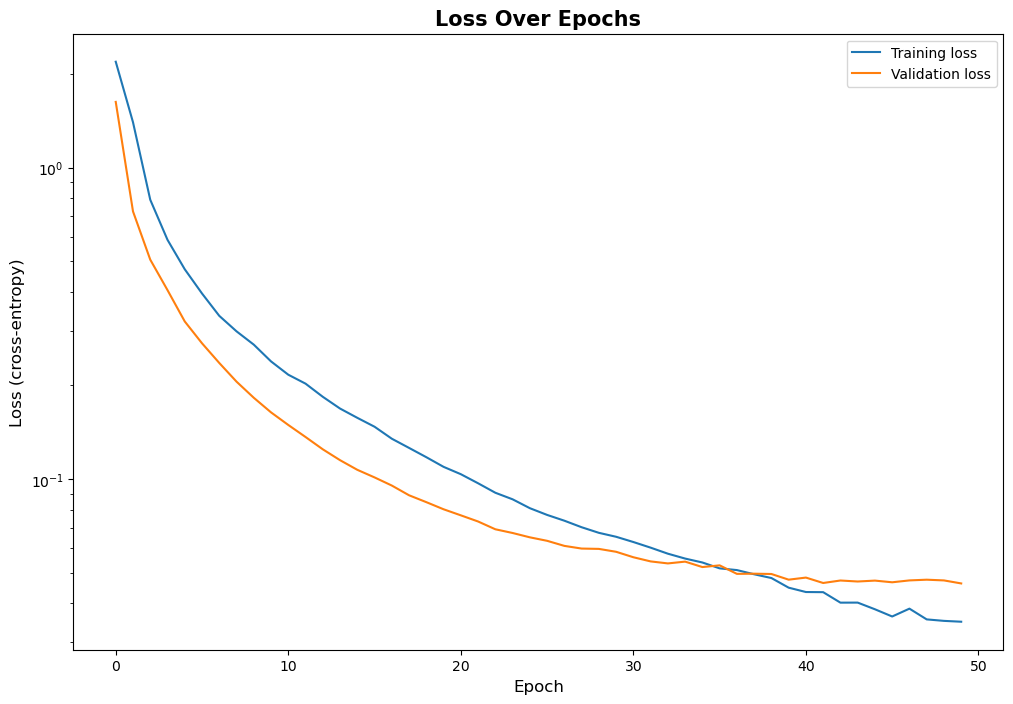

In [56]:
def plot_losses(size, losses, labels):
  """Draws line plots of losses (i.e., model errors) vs. epoch number.
  
  Parameters:
  size -- figsize (tuple)
  losses -- the losses to draw (list)
  labels -- the graph's labels (list)
  """

  plt.figure(figsize=(size[0],size[1]))
  plt.semilogy(losses[0], label=labels[0])
  plt.semilogy(losses[1], label=labels[1])
  plt.title(label="Loss Over Epochs",
            fontweight="bold",
            fontsize=15)
  plt.xlabel(xlabel="Epoch",
             fontsize=12)
  plt.ylabel(ylabel="Loss (cross-entropy)",
             fontsize=12)
  plt.legend()
  plt.savefig("/home/matteo/Documents/phd/year3/cnns-tutorial-paper/files/losses.png",
              dpi=300)
  plt.show()
  
plot_losses(size=(12,8),
            losses=losses,
            labels=["Training loss", "Validation loss"])

Apparently, both the training and validation loss decayed exponentially over training epochs. 

Curiously, the validation loss was systematically lower than the training loss for the first 22/23 epochs, then it stopped decreasing while the training loss kept going down.

This is a twofold phenomenon that opens the door to some discussion about learning in ANNs. 

#### **The validation loss was lower than the training loss**

Assuming no bugs, this can be due to various reasons. Among them:

1. The training process is subject to **regularisation**, while the validation process is not. This means that training is intentionally underpowered to prevent the ANN from [overfitting](https://en.wikipedia.org/wiki/Overfitting) - that is, finding weights that are too specific to training data and would not work on validation or test data (we used dropout and weight decay as regularisation techniques). As a result, the performance on the training data is a bit worse than the network's true potential 

2. The validation dataset contains easier samples than the training dataset. As the two datasets are created with a random split of one father dataset, this is possible (but not necessarily likely) 

#### **The validation loss stopped decreasing, while the training loss kept decreasing**

This means that the network started to overfit (around epoch 22/23). We could have stopped training at that point, and test performance would have not changed.

## **Finally: The Test** <a class="anchor" id="finally-the-test"></a>

The code below tests the trained network on peviously unseen samples (i.e., the test dataset). 

It's basically the same as previous code for training-validation, with the difference that we use accuracy (instead of loss) as a performance metric (more interpretable):

In [59]:
def test(model, device, dataloader):
  """Evaluates the model on novel samples.
  
  Parameters:
  model -- a PyTorch model instance
  device -- where to run computations (torch device object)
  dataloader -- a PyTorch dataloader instance
  """

  images = []
  labels = []
  outputs = []
  model.eval()
  with torch.no_grad():
    for sample in dataloader:
      image = sample[0].to(device)
      label = sample[1].to(device)
      output = model(image)
      images.append(image)
      labels.append(label)
      outputs.append(output)
  images = torch.cat(images)
  labels = torch.cat(labels)
  outputs = torch.cat(outputs)
  correct = outputs.argmax(dim=1).eq(labels).sum()
  accuracy = correct*100/len(labels)
  print(f"TEST ACCURACY: {accuracy: .2f}%")
  return outputs

test_outputs = test(model=model,
                    device=device,
                    dataloader=test_loader)

TEST ACCURACY:  98.82%


## **Inspecting a Trained Model: Basic Techniques** <a class="anchor" id="inspecting-a-trained-model-basic-techniques"></a>

Once trained and tested a network, you might want to characterise its behaviour. 

In particular, you might want to understand what input features drive its performance, or what classes are easier vs. harder to discriminate.  

Among the many techniques to characterise a model's behaviour, a confusion matrix is perhaps the simplest. 

This is simply a matrix that stores the number of corrects vs. incorrect responses for each class in the dataset:

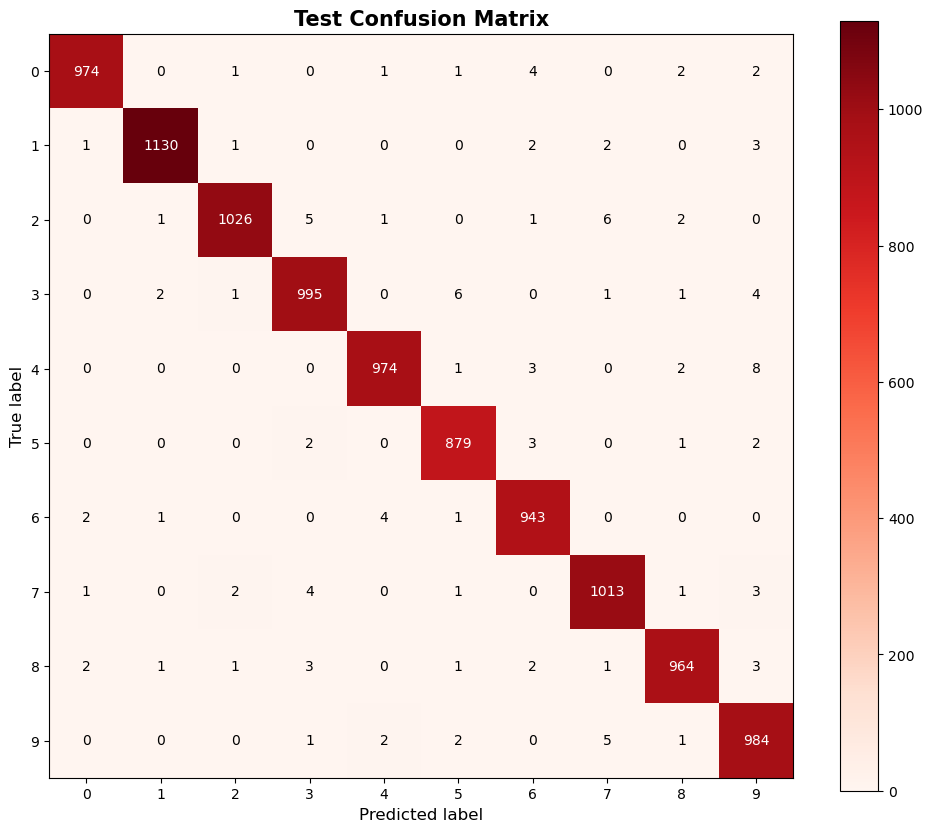

In [61]:
from sklearn.metrics import confusion_matrix as sklearn_confusion

def plot_confusion_matrix(true, predicted, classes):
  """Plots a heatmap-style confusion matrix. 

  Parameters:
  true -- ground truth labels (array-like)
  predicted -- labels predicted by the model (array-like)
  classes -- the number of classes in the dataset (int)
  """
  
  matrix = sklearn_confusion(true, predicted)
  plt.figure(figsize=(12,10))
  plt.imshow(matrix, interpolation = 'nearest', cmap ='Reds')
  matrix_cells = product(range(matrix.shape[0]), range(matrix.shape[1]))
  for row_index, column_index in matrix_cells:
    plt.text(x=row_index, 
             y=column_index, 
             s=matrix[row_index][column_index],
             horizontalalignment="center",
             verticalalignment="center",
             color="white" if row_index == column_index else "black")
  ticks = np.arange(classes)
  plt.xticks(ticks)
  plt.yticks(ticks)
  plt.xlabel(xlabel="Predicted label",
             fontsize=12)
  plt.ylabel(ylabel="True label",
             fontsize=12)
  plt.title(label="Test Confusion Matrix",
            fontweight="bold",
            fontsize=15)
  plt.colorbar()
  plt.savefig("/home/matteo/Documents/phd/year3/cnns-tutorial-paper/files/confusion-matrix.png",
              dpi=300)
  return matrix


true_image_labels = test_dataset.targets.cpu().numpy()
predicted_image_labels = torch.argmax(input=test_outputs,dim=1).cpu().numpy()

confusion_matrix = plot_confusion_matrix(true=true_image_labels,
                                         predicted=predicted_image_labels,
                                         classes=10)

While interesting, the confusion matrix is not explicit about which classes are easier vs. harder to learn. 

To obtain this information, we can count the number of mistakes per class and plot them with a bar chart:

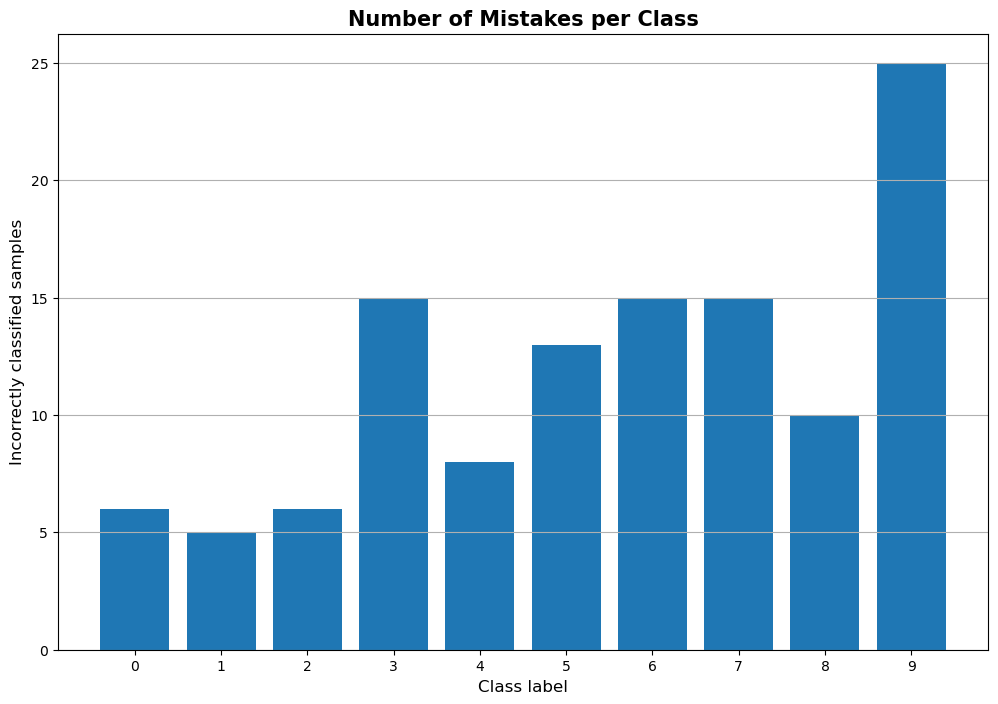

In [64]:
def plot_incorrect(dataset, confusion_matrix, classes):
  """Creates a bar chart of test mistakes per class.
  
  Parameters:
  dataset -- a PyTorch dataset
  confusion_matrix -- a confusion matrix (2darray)
  classes -- the number of classes in the dataset (int)
  """

  bins = dataset.targets.bincount()
  incorrect = [bins[i] - confusion_matrix[i][i] for i in range(len(bins))] 
  bars = np.arange(classes) 
  plt.figure(figsize=(12,8))
  plt.bar(bars, incorrect)
  plt.xticks(bars)
  plt.xlabel(xlabel="Class label",
             fontsize=12)
  plt.ylabel(ylabel="Incorrectly classified samples",
             fontsize=12)
  plt.title(label="Number of Mistakes per Class",
            fontweight="bold",
            fontsize=15)
  plt.grid(axis="y")
  plt.savefig("/home/matteo/Documents/phd/year3/cnns-tutorial-paper/files/mistakes-barplot.png",
            dpi=300)

plot_incorrect(dataset=test_dataset,
               confusion_matrix=confusion_matrix,
               classes=10)

[Back to top](#back-to-top)

# **Moving Forward: Exercises**

We have covered quite a lot of material! 

I intentionally left out practicals because I wanted enough time to convey the basic concepts. If you still want to tinker with CNNs, you can: 

1. Play around with the hyperparameters:
    - What happens without dropout? 
    - What happens without weight decay?
    - What happens with a different learning rate?
    - What happens with smaller/larger convolution kernels?
    - What happens with convolution strides larger than one?
    - What happens with more/less convolutional/linear layers?
    
2. Try a random search instead of our grid search

3. Play around with my code: make changes, watch them break the code, understand why they do

4. Use a different dataset: [`torchvision` contains many](https://pytorch.org/vision/stable/datasets.html)
    - Are the current hyperparameters fit for a new dataset?

# **Moving Forward 2: Readings & Tutorials**

Unlike the neuroscientific community, the machine learning community is incredibly prone to open science. 

The Internet is full of high-quality readings and tutorials - many of which have a non-academic approach (and are great nonetheless). 

While it's impossible to collect all pointers here, I can list a few essentials (all of which have been made freely available by the authors).

## **Machine/Deep Learning Concepts**

- One-stop shop for deep learning concepts. Academic book. Provides a thorough treatment of almost everything there is to know. [Link](https://www.deeplearningbook.org/)

- Good Coursera course by leading expert Andrew Ng. [Link](https://www.coursera.org/learn/neural-networks-deep-learning)
    - And another one about training strategies. [Link](https://www.coursera.org/learn/deep-neural-network#modules)

- Stanford course on CNNs. [Link](https://cs231n.stanford.edu/)

## **Mathematical Background**

- Old lecture notes by Mark van Rossum, then at the University of Edinburgh. Clear and concise. Chapters 1-5 are relevant (but ignore paragraphs 4.2 and 4.4). [Link](https://www.inf.ed.ac.uk/teaching/courses/fmcs1/lecture_notes/lecture_notes_neural.pdf)

- Video introductions to linear algebra. Non-academic, incredibly high quality. Contain more than necessary. [Link](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)

- Video introductions to calculus. Non-academic, incredibly high quality. Contain more than necessary. [Link](https://www.youtube.com/watch?v=WUvTyaaNkzM&list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr)

- One-stop shop for machine learning mathematics. Academic book. [Link](https://mml-book.github.io/)
    - There is an associated Coursera learning path. [Link](https://www.coursera.org/specializations/mathematics-machine-learning)